# Exercise - Investigate Trending Skills

In [2]:
# importing libraries
import ast
import pandas as pd 
from datasets import load_dataset
import matplotlib.pyplot as plt 

# load data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# data clean up 
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\HP\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()

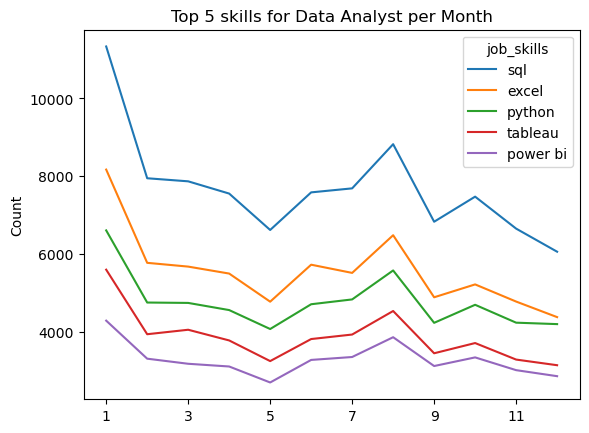

In [21]:
df_DA['job_posted_month_no'] = df_DA['job_posted_date'].dt.month
df_Da_explode = df_DA.explode('job_skills')
df_da_pivot = df_Da_explode.pivot_table(index = 'job_posted_month_no', columns = 'job_skills', aggfunc='size', fill_value=0)
df_da_pivot.loc['Total'] = df_da_pivot.sum()
df_da_pivot = df_da_pivot[df_da_pivot.loc['Total'].sort_values(ascending = False).index]
df_da_pivot = df_da_pivot.drop('Total')
df_da_pivot.iloc[:,:5].plot(kind = 'line')
plt.title('Top 5 skills for Data Analyst per Month')
plt.ylabel('Count')
plt.xlabel('')
plt.show()

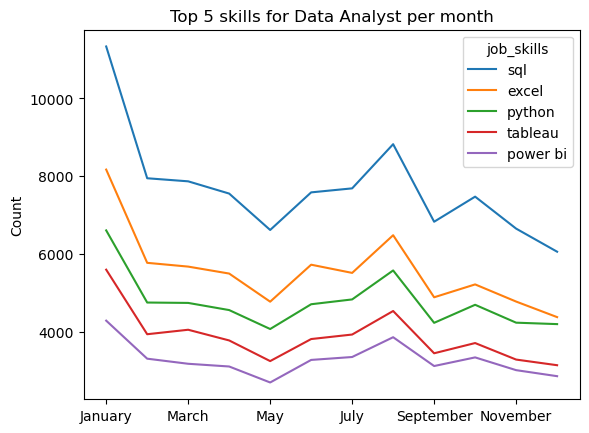

In [30]:
df_Da_pivot = df_Da_pivot.reset_index()
df_Da_pivot['job_posted_month'] = df_Da_pivot['job_posted_month_no'].apply(lambda x:pd.to_datetime(x, format = '%m').strftime(format = '%B'))
df_Da_pivot = df_Da_pivot.set_index('job_posted_month')
df_Da_pivot = df_Da_pivot.drop(columns='job_posted_month_no')

df_Da_pivot.iloc[:, :5].plot(kind = 'line')

plt.title('Top 5 skills for Data Analyst per month')
plt.xlabel('')
plt.ylabel('Count')
plt.show()